In [69]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, when, avg, expr, log1p, expm1, abs
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.types import FloatType, IntegerType
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv


In [70]:
spark=SparkSession.builder.appName('Inspecting_healthcare').getOrCreate()

In [71]:
load_dotenv()
#Create the folder with the csv files and store it in your preferred locaton in your PC. Do not push the csv files on github LOL.

base_path=os.getenv('FOLDER_PATH')

url=base_path+"/final_data.csv" 
data=spark.read.option('header','true').option('inferSchema','true').csv(url)

In [72]:
data.show()

+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|                  1|   00100|             N|            F|              239|      219|    322.0|               322|  1069.9324224|2013|
|                  1|   00103|             N|            F|              515|     2394|   4206.0|              4206|  610.75801474|2013|
|                  1|   00104|             N|            F|              286|      309|   3103.0|              3103|  396.53074444|2013|
|                  1|   00120|             N|            F|              363|      615|    986.0|               985|  711.17103448|2013|
|                  1|   00124|           

In [73]:
# invalid=data.filter(expr('try_cast(Rndrng_Prvdr_Geo_Cd as int)').isNull())
# invalid.groupBy('Rndrng_Prvdr_Geo_Cd','Rndrng_Prvdr_Geo_Desc').count().show()

# # data.filter(col('Rndrng_Prvdr_Geo_Cd').isin('9A','9B','9C','9D','9E')).groupBy('Rndrng_Prvdr_Geo_Cd','Rndrng_Prvdr_Geo_Desc').count().show()

In [74]:
# invalid=data.filter(expr('try_cast(Rndrng_Prvdr_Geo_Cd as int)').isNull())
# invalid.groupBy('Rndrng_Prvdr_Geo_Cd','Rndrng_Prvdr_Geo_Desc').count().show()

In [75]:
# X.select('Place_Of_Srvc').distinct().count()
X=data.select('*')
columns_scale=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']

X=X.withColumn('Rndrng_Prvdr_Geo_Cd',expr("try_cast(Rndrng_Prvdr_Geo_Cd as int)"))
X=X.withColumn('Avg_Sbmtd_Chrg',expr("try_cast(Avg_Sbmtd_Chrg as double)"))

for column in columns_scale:
    # X=X.withColumn(column,expr(f"try_cast({column} as int)"))
    X=X.withColumn(column,log1p(col(column)))


In [76]:
X.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+
|                  1|   00100|             N|            F| 5.480638923341991| 5.393627546352361| 5.777652323222656| 5.777652323222656|  1069.9324224|2013|
|                  1|   00103|             N|            F| 6.246106765481563| 7.781138509845015| 8.344505083590521| 8.344505083590521|  610.75801474|2013|
|                  1|   00104|             N|            F| 5.659482215759621| 5.736572297479192|  8.04044688130311|  8.04044688130311|  396.53074444|2013|
|                  1|   00120|             N|            F|5.897

In [77]:
columns_sindexer=['HCPCS_Cd','HCPCS_Drug_Ind','Place_Of_Srvc']
ouput_sindexer=['HCPCS_Cd_indexed','HCPCS_Drug_Ind_indexed','Place_Of_Srvc_indexed']

#indexing
string_indexer=StringIndexer(inputCols=columns_sindexer,
                             outputCols=ouput_sindexer)

#year can be hot encoded
year_indexer = StringIndexer(
    inputCol='year',
    outputCol='year_index',
)

year_encoder = OneHotEncoder(
    inputCol='year_index',
    outputCol='year_ohe'
)

#vectorize to scale
scale_assembler=VectorAssembler(inputCols=columns_scale,
                                outputCol='scaling_features')

#scaling #check if log transfor need to be used for the other columns not just the target!!!!!
scaler=StandardScaler(inputCol='scaling_features',
                      outputCol='scaled_features')
#vectorizing everything
assembler=VectorAssembler(
    inputCols=['Rndrng_Prvdr_Geo_Cd']+ouput_sindexer+['year_ohe','scaled_features'],
 outputCol='Features_Col'
)

#Linear Regression
lr=LinearRegression(featuresCol='Features_Col',
                    labelCol='Avg_Sbmtd_Chrg')

#Pipeline
pipeline=Pipeline(stages=[
    string_indexer,
    year_indexer,
    year_encoder,
    scale_assembler
    ,scaler,assembler
    ,lr])

model=pipeline.fit(X)
new_X=model.transform(X)

In [78]:
new_X.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+----------------+----------------------+---------------------+----------+----------+--------------------+--------------------+--------------------+------------------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|year_index|  year_ohe|    scaling_features|     scaled_features|        Features_Col|        prediction|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+----------------+----------------------+---------------------+----------+----------+--------------------+--------------------+--------------------+------------------+
|                  1|   00100|    

In [79]:
new_X.groupBy("Year").count().orderBy("Year").show()

+----+------+
|Year| count|
+----+------+
|2013|251600|
|2014|251608|
|2015|253084|
|2016|256144|
|2017|256139|
|2018|257249|
|2019|259317|
|2020|254079|
|2021|257325|
|2022|256279|
|2023|254097|
+----+------+



In [80]:
evaluator=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
                              predictionCol='prediction',
                              metricName='rmse')

rmse=evaluator.evaluate(new_X)

print(f'rmse: {rmse}')

rmse: 2098.9793075711023


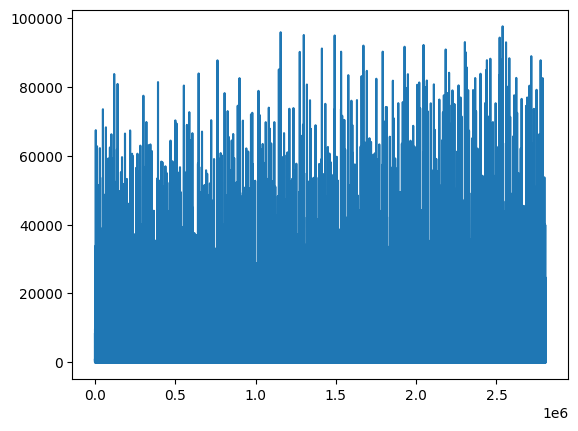

In [81]:
new_X=new_X.withColumn('Residuals',abs(col('Avg_Sbmtd_Chrg')-col('prediction')))
residuals=new_X.select('Residuals').toPandas()

plt.plot(range(len(residuals)),residuals)

Extra Stuff

In [82]:
# new_X=new_X.withColumn('original_pred',expm1(col('prediction')))

In [83]:
# evaluator=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
#                               predictionCol='original_pred',
#                               metricName='rmse')

# rmse=evaluator.evaluate(new_X)

# print(f'rmse: {rmse}')

In [84]:
new_X.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+----------------+----------------------+---------------------+----------+----------+--------------------+--------------------+--------------------+------------------+------------------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|year_index|  year_ohe|    scaling_features|     scaled_features|        Features_Col|        prediction|         Residuals|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+----------------+----------------------+---------------------+----------+----------+--------------------+--------------------+--------------------+----------------

In [85]:
#Utah:49
utah=new_X.filter(col('Rndrng_Prvdr_Geo_Cd')==49)

In [86]:
utah.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+----------------+----------------------+---------------------+----------+----------+--------------------+--------------------+--------------------+------------------+------------------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|year_index|  year_ohe|    scaling_features|     scaled_features|        Features_Col|        prediction|         Residuals|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+----------------+----------------------+---------------------+----------+----------+--------------------+--------------------+--------------------+----------------

In [87]:
# utah=utah.limit(5000)
# utah.count()

In [88]:
null_counts = new_X.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in new_X.columns
])

null_counts.show()

+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+----------------+----------------------+---------------------+----------+--------+----------------+---------------+------------+----------+---------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|year_index|year_ohe|scaling_features|scaled_features|Features_Col|prediction|Residuals|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+----------------+----------------------+---------------------+----------+--------+----------------+---------------+------------+----------+---------+
|                  0|       0|             0|            0|                0|        0|        0|                 0|             0|   0|      

array([[<Axes: title={'center': 'Tot_Rndrng_Prvdrs'}>]], dtype=object)

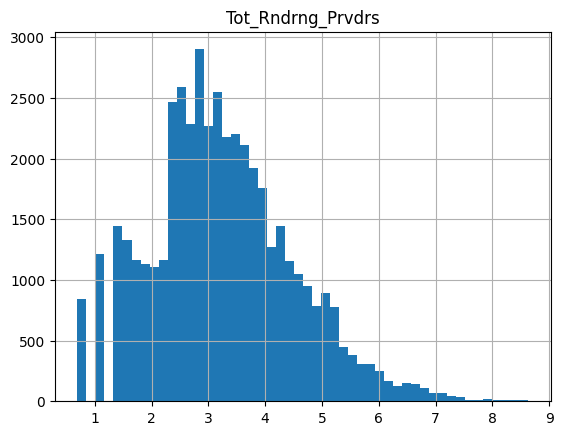

In [89]:
columns_scale=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
utah.select("Tot_Rndrng_Prvdrs").toPandas().hist(bins=50)

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

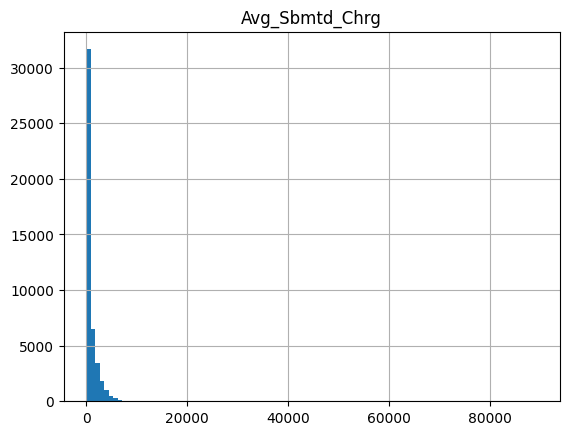

In [90]:
utah.select("Avg_Sbmtd_Chrg").toPandas().hist(bins=100)

In [91]:
utah.columns

['Rndrng_Prvdr_Geo_Cd',
 'HCPCS_Cd',
 'HCPCS_Drug_Ind',
 'Place_Of_Srvc',
 'Tot_Rndrng_Prvdrs',
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Bene_Day_Srvcs',
 'Avg_Sbmtd_Chrg',
 'Year',
 'HCPCS_Cd_indexed',
 'HCPCS_Drug_Ind_indexed',
 'Place_Of_Srvc_indexed',
 'year_index',
 'year_ohe',
 'scaling_features',
 'scaled_features',
 'Features_Col',
 'prediction',
 'Residuals']

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

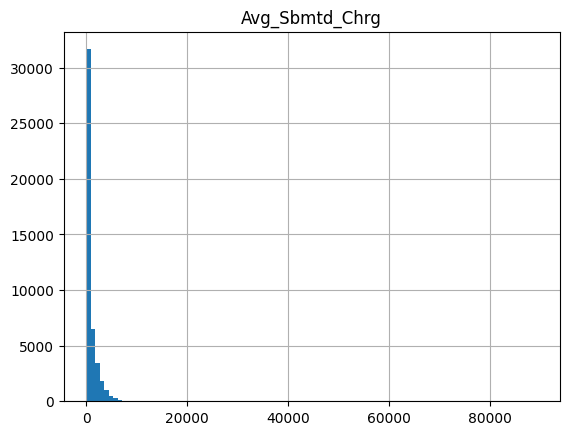

In [92]:
utah.select('Avg_Sbmtd_Chrg').toPandas().hist(bins=100)

In [93]:
utah.describe('Avg_Sbmtd_Chrg').show()

+-------+------------------+
|summary|    Avg_Sbmtd_Chrg|
+-------+------------------+
|  count|             45616|
|   mean| 935.6660448626668|
| stddev|1834.4046655742768|
|    min|              0.01|
|    max|           89225.0|
+-------+------------------+

